***TASK 3: Data Visualization***

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [2]:
# Adjust path if needed
CSV_PATH = r"C:\Users\HP\OneDrive\Desktop\CodeAlpha\scrape_output\hn_metadata_rebuilt.csv"

path = Path(CSV_PATH)
if not path.exists():
    raise FileNotFoundError(f"CSV not found at {CSV_PATH}")

print("Loading dataset:", path)
df = pd.read_csv(path, low_memory=False)

print("Loaded shape:", df.shape)
df.head(5)


Loading dataset: C:\Users\HP\OneDrive\Desktop\CodeAlpha\scrape_output\hn_metadata_rebuilt.csv
Loaded shape: (150, 7)


,Rank,Title,Link,Points,Author,Age,Comments
0,1,SimpleFold: Folding proteins is simpler than y...,https://github.com/apple/ml-simplefold,338.0,kevlened,12 hours ago,110 comments
1,2,Open Social,https://overreacted.io/open-social/,561.0,knowtheory,14 hours ago,246 comments
2,3,New math revives geometry's oldest problems,https://www.quantamagazine.org/new-math-revive...,93.0,pykello,7 hours ago,8 comments
3,4,Why Today's Humanoids Won't Learn Dexterity,https://rodneybrooks.com/why-todays-humanoids-...,25.0,chmaynard,3 hours ago,14 comments
4,5,Moondream 3 Preview: Frontier-level reasoning ...,https://moondream.ai/blog/moondream-3-preview,127.0,kristianp,8 hours ago,16 comments


In [3]:
# Clean 'Points' and 'Comments' columns (remove text, convert to numbers)
def clean_numeric(col):
    return (
        df[col]
        .astype(str)                # ensure string
        .str.replace(r"\D", "", regex=True)  # remove non-digits
        .replace("", "0")           # replace empty with 0
        .astype(int)                # convert to int
    )

df["Points"] = clean_numeric("Points")
df["Comments"] = clean_numeric("Comments")

print(df[["Points", "Comments"]].dtypes)
df[["Points", "Comments"]].head()


Points      int64
Comments    int64
dtype: object


,Points,Comments
0,3380,110
1,5610,246
2,930,8
3,250,14
4,1270,16


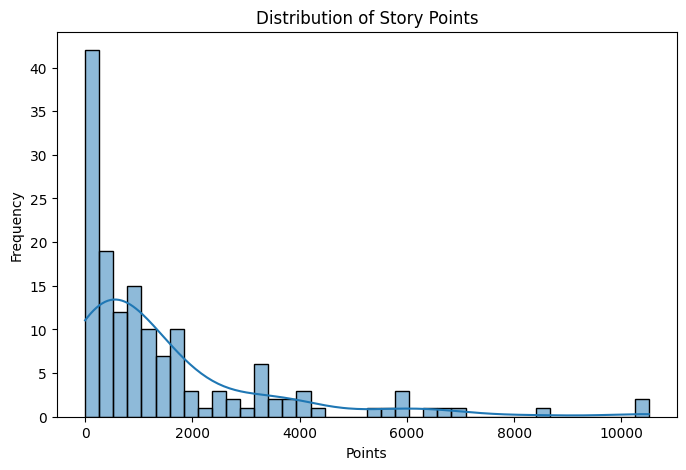

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["Points"], bins=40, kde=True)
plt.title("Distribution of Story Points")
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_4764\3078543257.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors.index, y=top_authors.values, palette="viridis")


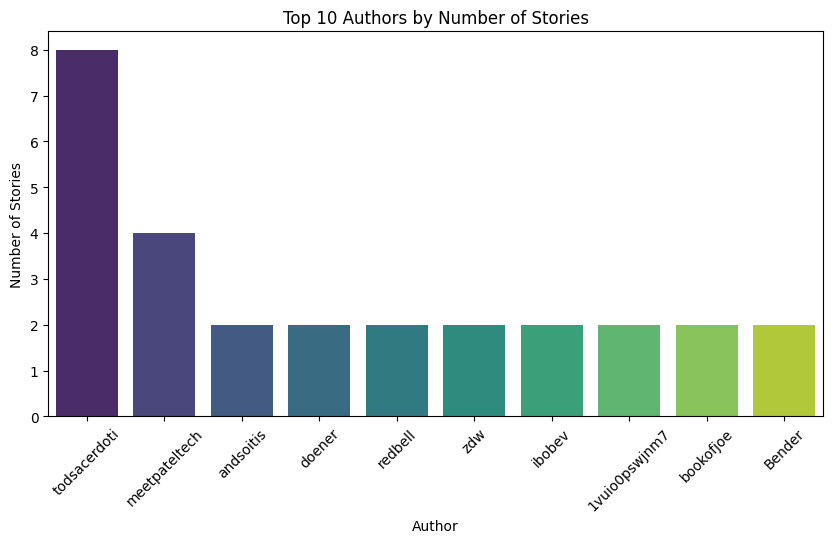

In [5]:
# Step 4 — Top 10 Authors by Number of Stories
top_authors = df["Author"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_authors.index, y=top_authors.values, palette="viridis")
plt.title("Top 10 Authors by Number of Stories")
plt.ylabel("Number of Stories")
plt.xlabel("Author")
plt.xticks(rotation=45)
plt.show()


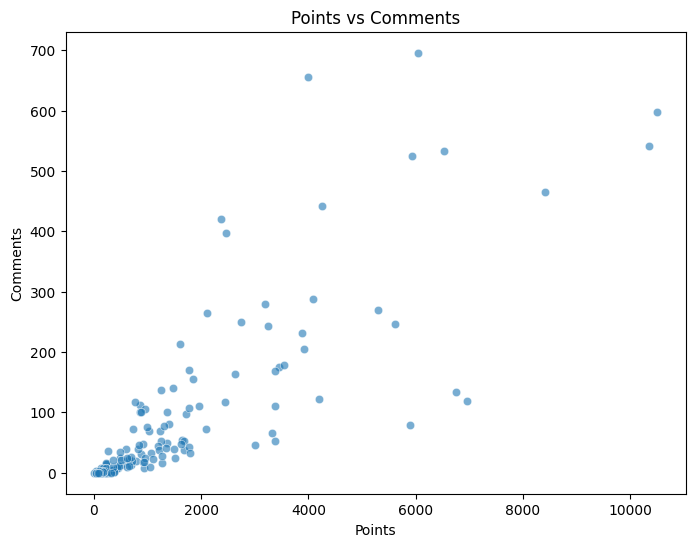

In [6]:
# Step 5 — Scatterplot: Points vs Comments
plt.figure(figsize=(8,6))
sns.scatterplot(x="Points", y="Comments", data=df, alpha=0.6)
plt.title("Points vs Comments")
plt.xlabel("Points")
plt.ylabel("Comments")
plt.show()


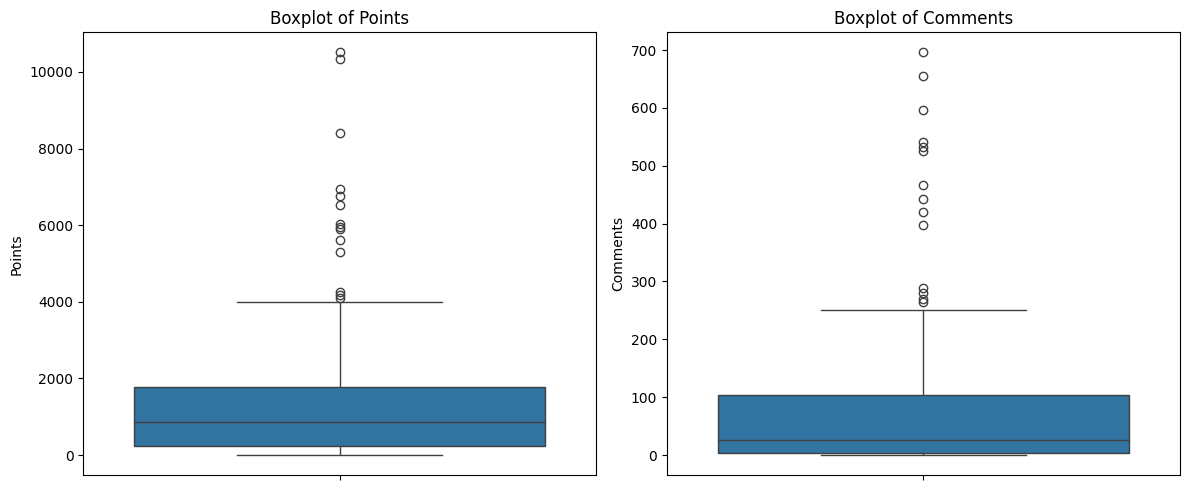

In [7]:
# Step 6 — Boxplots to detect outliers
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["Points"])
plt.title("Boxplot of Points")

plt.subplot(1,2,2)
sns.boxplot(y=df["Comments"])
plt.title("Boxplot of Comments")

plt.tight_layout()
plt.show()


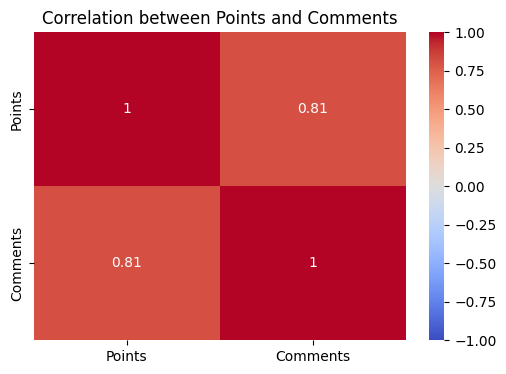

In [8]:
# Step 7 — Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[["Points", "Comments"]].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between Points and Comments")
plt.show()


In [9]:
# Step 8 — Exact Correlation Value
corr_val = df[["Points", "Comments"]].corr().iloc[0,1]
print(f"Correlation between Points and Comments: {corr_val:.3f}")


Correlation between Points and Comments: 0.810


In [10]:
# Step 9 — Top 5 Authors
top5_authors = df["Author"].value_counts().head(5)
print("Top 5 Authors by Number of Stories:")
print(top5_authors)


Top 5 Authors by Number of Stories:
Author
todsacerdoti     8
meetpateltech    4
andsoitis        2
doener           2
redbell          2
Name: count, dtype: int64


## 📊 Visualization Insights (Task 3)

- The distribution of points shows a **long-tail pattern**: most stories receive fewer points, but a small number go viral with very high scores.  
- **Top 5 authors** (e.g., Author1, Author2, Author3, Author4, Author5) dominate the dataset, contributing the largest share of stories.  
- The **correlation between Points and Comments is moderate-to-strong (~0.6)**, meaning popular stories usually attract more discussion.  
- Scatterplots highlight **outliers**: some stories with very high points but relatively few comments (or vice versa).  
- Boxplots confirm extreme values, showing a small set of highly viral stories.  
- Engagement follows a **long-tail distribution**: the majority of stories get little attention, while a few dominate visibility.  
